# 11 — Interpretability: Grad-CAM · Deliverable 2

Two models, one validation set, **four outputs**:

1. **Paired Grad-CAM panel** — the same five validation images through both models, side by side.
2. **Grad-CAM on the DenseNet failures** — what the final model was looking at when it was wrong.
3. **On-leaf attention for both models**, measured against PlantVillage's own segmented masks:
   leaf area, attention share, concentration, plus a **paired bootstrap CI** on the difference.
4. **Significance test** on the correct-vs-wrong concentration gap.

**Validation only. The test set is sealed** — its CSV is hashed for the fingerprint and never read as data.

Figures go to `04_figures/`, numbers to `03_results/`.

> **Before you run:** Runtime ▸ Change runtime type ▸ **T4 GPU**, then Runtime ▸ Run all.
> About **20–30 minutes** end to end. Set `SMOKE_TEST = True` in §2 for a ~3-minute dry run
> that writes to `_SMOKE` filenames and cannot overwrite a real result.

## 1. Colab setup

Kaggle credentials from Secrets (the API times out intermittently, hence the retry) and Drive mounted.
The raw images live on the **local runtime disk** — fast; Drive holds only the split, the models and the outputs.

In [ ]:
# Kaggle credentials from Colab Secrets (with retry) + mount Drive
import os, time

ON_COLAB = False
try:
    from google.colab import userdata, drive
    ON_COLAB = True
except ModuleNotFoundError:
    print("Not on Colab - expecting ~/.kaggle/kaggle.json and a local mirror of the Drive tree.")

if ON_COLAB:
    ok = False
    for attempt in range(1, 4):
        try:
            os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
            os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
            print(f"Kaggle credentials loaded from Colab Secrets (attempt {attempt}).")
            ok = True
            break
        except Exception as e:
            print(f"  attempt {attempt}: Secrets not ready ({type(e).__name__}); retrying in 3s...")
            time.sleep(3)
    if not ok:
        print("")
        print("Colab Secrets did not respond. Fixes, in order:")
        print("  1) RE-RUN this cell - the timeout is almost always transient.")
        print("  2) Left sidebar -> key icon -> confirm KAGGLE_USERNAME and KAGGLE_KEY exist,")
        print("     each with 'Notebook access' toggled ON, then re-run.")
        print("  3) Still failing? Set os.environ['KAGGLE_USERNAME'/'KAGGLE_KEY'] manually here.")
    drive.mount("/content/drive")

import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
print("\nTensorFlow", tf.__version__, "| GPU:", gpus if gpus else "NONE - switch the runtime to T4")

  attempt 1: Secrets not ready (TimeoutException); retrying in 3s...
Kaggle credentials loaded from Colab Secrets (attempt 2).
Mounted at /content/drive

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

The only config block in the notebook. Both model paths are **hard-coded** — no scanning, no guessing.
If a path is wrong the load fails immediately and says so, which is the behaviour you want.

In [ ]:
# ---- the one config block ----
from pathlib import Path
from collections import deque
import sys, subprocess, hashlib, random, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import keras
%matplotlib inline

SEED = 42
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)

# ---- the split this notebook is allowed to run on ----
SPLIT_ID_EXPECTED = "9e33ec57c1ec"

# ---- Drive layout (hard-coded) ----
D2         = Path("/content/drive/MyDrive/plant_recognition/deliverable2")
SPLIT_DIR  = D2 / "00_split"
RESULTS    = D2 / "03_results"
FIGURES    = D2 / "04_figures"
RESULTS.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)
SPLIT_CSV  = {s: SPLIT_DIR / f"split_{s}.csv" for s in ("train", "val", "test")}

# ---- the two models, hard-coded ----
SCRATCH_PATH  = D2 / "02_models" / "scratch_cnn.keras"
DENSENET_PATH = D2 / "02_models" / "densenet121.keras"
SCRATCH_NAME  = "Scratch CNN"
DENSENET_NAME = "DenseNet-121"
ORDER         = [SCRATCH_NAME, DENSENET_NAME]     # baseline first, final model second

# ---- raw images (local runtime disk) ----
PV_DIR   = Path.home() / "plant_recognition" / "plantvillage"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- recipe (must match how both models were trained) ----
IMG_SIZE   = 128
BATCH_SIZE = 32

# ---- output 1: the five images in the paired panel ----
PANEL_CLASSES = [
    "Corn_(maize)___Northern_Leaf_Blight",   # required - the lesion-streak case
    "Tomato___healthy",                      # required - the healthy-leaf case
    "Apple___Apple_scab",
    "Grape___Black_rot",
    "Potato___Late_blight",
]

# ---- output 2 / 3 / 4 knobs ----
N_FAILURES = 6        # DenseNet failures shown in the failure panel
N_ATTENTION = None    # None = every validation image with a segmented mask
N_BOOT      = 2000    # bootstrap resamples
MASK_THRESH = 12      # a segmented pixel counts as leaf if max(R,G,B) > this

# ---- run switches ----
SMOKE_TEST      = False   # True -> 200 attention images, _SMOKE filenames, real results untouched
SMOKE_N         = 200
FORCE_RECOMPUTE = False   # True -> ignore the cached CSVs and redo the heavy passes

TAG = "_SMOKE" if SMOKE_TEST else ""
if SMOKE_TEST:
    N_ATTENTION = SMOKE_N

OUT = {
    "preds":     RESULTS / f"val_predictions{TAG}.csv",
    "failures":  RESULTS / f"densenet_failures{TAG}.csv",
    "attention": RESULTS / f"attention_on_leaf{TAG}.csv",
    "summary":   RESULTS / f"attention_summary{TAG}.csv",
    "bootstrap": RESULTS / f"attention_bootstrap{TAG}.csv",
    "corrwrong": RESULTS / f"attention_correct_vs_wrong{TAG}.csv",
}
FIG = {
    "panel":     FIGURES / f"gradcam_paired_panel{TAG}.png",
    "failures":  FIGURES / f"gradcam_densenet_failures{TAG}.png",
    "attention": FIGURES / f"attention_on_leaf{TAG}.png",
    "corrwrong": FIGURES / f"attention_correct_vs_wrong{TAG}.png",
}

print("deliverable2 :", D2)
print("scratch CNN  :", SCRATCH_PATH)
print("DenseNet-121 :", DENSENET_PATH)
print(f"recipe       : {IMG_SIZE}px, batch {BATCH_SIZE}, seed {SEED}")
print(f"switches     : SMOKE_TEST={SMOKE_TEST}, FORCE_RECOMPUTE={FORCE_RECOMPUTE}, TAG='{TAG}'")

deliverable2 : /content/drive/MyDrive/plant_recognition/deliverable2
scratch CNN  : /content/drive/MyDrive/plant_recognition/deliverable2/02_models/scratch_cnn.keras
DenseNet-121 : /content/drive/MyDrive/plant_recognition/deliverable2/02_models/densenet121.keras
recipe       : 128px, batch 32, seed 42
switches     : SMOKE_TEST=False, FORCE_RECOMPUTE=False, TAG=''


## 3. The split, and the fingerprint

`SPLIT_ID` is an MD5 over the three split CSVs' digests. It must equal `9e33ec57c1ec`, the value frozen by
`00_setup_and_split.ipynb`. **A mismatch stops the notebook.** Every number in the report is comparable only
because every notebook ran on these exact files.

Note what happens to the test split here: its **bytes are hashed** and nothing else. It is never parsed,
never loaded, never scored. That is the whole of its involvement in this notebook.

**Why run it:** an interpretability result computed on a different split is not comparable to the model
scores it is supposed to explain.

**How it fits:** it is the same gate every Deliverable 2 notebook opens with.

In [ ]:
# Load the frozen split, re-derive SPLIT_ID, stop on mismatch
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

for s, p in SPLIT_CSV.items():
    assert p.exists(), f"missing {p} - run 00_setup_and_split.ipynb first"

digests  = {s: md5(SPLIT_CSV[s]) for s in ("train", "val", "test")}
SPLIT_ID = hashlib.md5("".join(digests[s] for s in ("train", "val", "test")).encode()).hexdigest()[:12]

print("SPLIT_ID =", SPLIT_ID, " (expected", SPLIT_ID_EXPECTED + ")")
if SPLIT_ID != SPLIT_ID_EXPECTED:
    raise SystemExit(
        f"\nSTOP. SPLIT_ID {SPLIT_ID} != {SPLIT_ID_EXPECTED}.\n"
        "The split CSVs on Drive are not the ones every other notebook ran on. Do not use any number\n"
        "produced below. Check 00_split/fingerprint.txt before going further."
    )

val_df = pd.read_csv(SPLIT_CSV["val"])            # validation only; test is hashed, never read
p_val  = val_df["filepath"].values
y_val  = val_df["label"].values
print(f"validation rows: {len(val_df):,}  |  classes present: {val_df['label'].nunique()}")
print("test split: hashed for the fingerprint, not loaded.")

SPLIT_ID = 9e33ec57c1ec  (expected 9e33ec57c1ec)
validation rows: 8,146  |  classes present: 38
test split: hashed for the fingerprint, not loaded.


## 4. Images and masks on disk

Two renderings are needed: `color` (what the models were trained on) and `segmented` (the dataset authors'
own background-masked version, which gives a free leaf outline for every image). The download is skipped if
the images are already on the runtime disk.

Two things this cell handles that would otherwise bite:

- **Absolute paths in the split CSVs.** They were written on a previous runtime. If they no longer resolve,
  the `<class>/<file>` tail is re-anchored under the `color` folder found here. The *file list* is unchanged —
  only where it is rooted.
- **Segmented filenames are not identical to colour filenames.** Many carry a `_final_masked` suffix and the
  extension case varies. We index each class's segmented folder on a normalised stem and match against it.
  Any image without a mask is dropped from §10 only — §7–§9 still use the full validation set.

**Why run it:** the mask is what turns a heatmap into a number.

**How it fits:** §10's leaf area, attention share and concentration are all computed against these masks.

In [ ]:
# Dataset on disk, then locate both renderings
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
    except ModuleNotFoundError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)
        from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Images already present:", PV_DIR)

def locate(root, names, max_depth=4):            # same BFS helper as every other notebook
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
SEG_DIR   = locate(PV_DIR, {"segmented"})
assert COLOR_DIR is not None, "no 'color' folder under PV_DIR"
assert SEG_DIR   is not None, "no 'segmented' folder under PV_DIR - the masks in section 10 need it"

class_names = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
assert len(class_names) == 38, f"expected 38 classes, found {len(class_names)}"
name2idx = {c: i for i, c in enumerate(class_names)}          # canonical sorted label order
yi_val   = np.array([name2idx[l] for l in y_val], dtype="int32")

print("color     :", COLOR_DIR)
print("segmented :", SEG_DIR)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:14<00:00, 150MB/s]



Downloaded to /root/plant_recognition/plantvillage
color     : /root/plant_recognition/plantvillage/plantvillage dataset/color
segmented : /root/plant_recognition/plantvillage/plantvillage dataset/segmented


In [ ]:
# Re-anchor the split paths if a previous runtime's absolute paths no longer resolve
def reanchor(p, root):
    parts = Path(str(p)).parts
    return str(root / parts[-2] / parts[-1])

n_probe = min(500, len(p_val))
hit = sum(Path(p).exists() for p in p_val[:n_probe])
if hit < 0.9 * n_probe:
    p_val = np.array([reanchor(p, COLOR_DIR) for p in p_val])
    hit = sum(Path(p).exists() for p in p_val[:n_probe])
    print(f"re-anchored the split paths under {COLOR_DIR}  ({hit}/{n_probe} sampled now resolve)")
else:
    print(f"split paths resolve as stored ({hit}/{n_probe} sampled)")
assert hit > 0.9 * n_probe, \
    "validation images still do not resolve - check the download and COLOR_DIR"

split paths resolve as stored (500/500 sampled)


In [ ]:
# Pair each validation image with its segmented twin (filenames differ by suffix / case)
SUFFIXES = ("_final_masked", "_masked", "_final", "_seg", "_segmented")

def norm_stem(stem):
    s = stem.lower().strip()
    for suf in SUFFIXES:
        if s.endswith(suf):
            s = s[: -len(suf)]
    return s.strip(" _-")

seg_index = {}
for cls in class_names:
    d = SEG_DIR / cls
    idx = {}
    if d.is_dir():
        for f in d.iterdir():
            if f.is_file() and f.suffix.lower() in IMG_EXTS:
                idx.setdefault(norm_stem(f.stem), f)
    seg_index[cls] = idx

mask_of, missing = {}, 0
for i, (p, lab) in enumerate(zip(p_val, y_val)):
    hit = seg_index.get(lab, {}).get(norm_stem(Path(p).stem))
    if hit is None:
        missing += 1
    else:
        mask_of[i] = hit

pct = 100 * len(mask_of) / len(p_val)
print(f"validation images with a segmented mask: {len(mask_of):,} / {len(p_val):,}  ({pct:.1f}%)")
print(f"without a mask (excluded from section 10 only): {missing:,}")
assert pct > 80, ("under 80% of validation images matched a mask - inspect SEG_DIR and the filename "
                  "convention before trusting any number in section 10.")

validation images with a segmented mask: 7,967 / 8,146  (97.8%)
without a mask (excluded from section 10 only): 179


## 5. The two models

Loaded from the hard-coded paths, `compile=False` (nothing is trained here). Both were built with their
preprocessing **inside** the model — `Rescaling(1/255)` for the scratch CNN, DenseNet's own
`preprocess_input` for the transfer model — so both are fed raw **0–255** pixels and neither gets any
preparation outside the graph.

The sanity check matters more than it looks. If the wrong checkpoint were loaded, or if the preprocessing
had not survived the save, accuracy on a real batch would collapse while every cell below still ran happily
and produced confident, meaningless heatmaps. The assertion refuses to let that happen quietly.

**Why run it:** everything downstream is an explanation *of these two objects*.

**How it fits:** the scratch CNN is the baseline attention profile; DenseNet-121 is the model whose
field-robustness claim §10 is meant to test.

In [ ]:
# Load both models and prove they are the right ones
def load_imgs(paths):
    out = [tf.image.resize(
               tf.io.decode_image(tf.io.read_file(str(p)), channels=3, expand_animations=False),
               [IMG_SIZE, IMG_SIZE]).numpy() for p in paths]
    return np.stack(out).astype("float32")

nets = {}
for disp, path in [(SCRATCH_NAME, SCRATCH_PATH), (DENSENET_NAME, DENSENET_PATH)]:
    assert path.exists(), f"{disp}: not found at {path}"
    nets[disp] = keras.models.load_model(path, compile=False)
    print(f"{disp:<14} loaded  |  {nets[disp].count_params():,} params  |  {path.name}")

# sanity: a real batch of 128 validation images must be classified well
rng   = np.random.default_rng(SEED)
probe = rng.choice(len(p_val), size=128, replace=False)
pimgs = load_imgs(p_val[probe])
print()
for disp, m in nets.items():
    acc = float((m.predict(pimgs, verbose=0).argmax(1) == yi_val[probe]).mean())
    print(f"{disp:<14} accuracy on a 128-image probe: {acc:.3f}")
    assert acc > 0.80, (f"{disp} scores {acc:.3f} on a clean probe - wrong checkpoint, or the "
                        "preprocessing did not survive the save. Stop and check before continuing.")
print("\nboth checkpoints verified.")

Scratch CNN    loaded  |  263,654 params  |  scratch_cnn.keras
DenseNet-121   loaded  |  7,076,454 params  |  densenet121.keras

Scratch CNN    accuracy on a 128-image probe: 0.961
DenseNet-121   accuracy on a 128-image probe: 0.992

both checkpoints verified.


## 6. Grad-CAM — the machinery

Take the deepest convolutional feature map — the last point at which information still has a *location*.
Compute the gradient of the predicted class score with respect to it; that says how much each channel
mattered. Average those gradients spatially into one weight per channel, take the weighted sum of the
channels, keep the positive part, resize onto the image. The result is a coarse map of *where the evidence
for this prediction was*.

**Why this needs custom code.** The two models have different shapes. The scratch CNN is flat, so its
convolutions are top-level layers. DenseNet-121 is a **nested** model sitting between a preprocessing chain
and a classifier head, and Keras 3 will not let you wire a tensor from inside a nested model to the outer
output. The cell below rebuilds each model as one flat graph on a fresh input, splitting the backbone open
on the way through — and, for the nested case, taking the pre-backbone segment straight from the original
graph rather than re-applying layers one by one. That last detail is not fussiness: DenseNet's
`preprocess_input` is applied as **graph operations, not `Layer` objects**, so a layer-by-layer rebuild drops
it silently and every heatmap below would be computed on an unpreprocessed input, with no error anywhere.
The assertion at the bottom is what catches that class of mistake — it demands the rebuilt graph reproduce
`model.predict` to within 1e-4.

**The resolution caveat, stated plainly.** At 128 px the scratch CNN's last feature map is **16×16** — 8 px
per cell — while DenseNet's is **4×4**, or 32 px per cell. DenseNet heatmaps will look blobbier no matter
what the model is doing, and a 4×4 map physically cannot follow a leaf edge. This belongs in the figure
caption, and §10 carries a matched-resolution control so the attention comparison is not just measuring
this.

**Why run it:** it is the machinery §7–§11 all sit on.

**How it fits:** one `gradcam()` call per model, identical interface, verified against both architectures.

In [ ]:
# Rebuild each model as a flat graph exposing (deep feature map, class probabilities)
CONV_LIKE = ("Conv2D", "SeparableConv2D", "DepthwiseConv2D",
             "Activation", "ReLU", "BatchNormalization")

def is_backbone(layer):
    """A nested Model that actually contains convolutions (excludes the augmentation block)."""
    return isinstance(layer, keras.Model) and any(
        l.__class__.__name__.endswith("Conv2D") for l in layer.layers)

def pick_target(sub):
    """Deepest layer with a 4-D, conv-like output."""
    for l in reversed(sub.layers):
        try:
            shp = l.output.shape
        except Exception:
            continue
        if len(shp) == 4 and l.__class__.__name__ in CONV_LIKE:
            return l
    raise ValueError("no 4-D conv-like layer found")

def build_grad_model(model):
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    bb  = next((l for l in model.layers if is_backbone(l)), None)

    if bb is None:                                  # flat model: the scratch CNN
        x, feat, tgt = inp, None, None
        for l in model.layers:
            if isinstance(l, keras.layers.InputLayer):
                continue
            x = l(x)
            if l.__class__.__name__ in CONV_LIKE and len(x.shape) == 4:
                feat, tgt = x, l
    else:                                           # nested backbone: DenseNet-121
        node  = bb._inbound_nodes[0]                 # the call that placed the backbone in the graph
        pre   = keras.Model(model.inputs, node.input_tensors[0], name="pre_backbone")
        head  = keras.Model(node.output_tensors[0], model.outputs[0], name="head")
        tgt   = pick_target(bb)
        split = keras.Model(bb.inputs, [tgt.output, bb.output], name="bb_split")
        feat, z = split(pre(inp))
        x = head(z)

    assert feat is not None, "target feature map never reached"
    return keras.Model(inp, [feat, x], name="gradcam"), tgt.name, tuple(feat.shape[1:3])

grad_models, grids = {}, {}
for disp, m in nets.items():
    gm, lname, grid = build_grad_model(m)
    grad_models[disp], grids[disp] = gm, grid
    print(f"{disp:<14} target '{lname}'  ->  {grid[0]}x{grid[1]} grid "
          f"({IMG_SIZE // grid[0]} px per cell)")

# the rebuilt graph must reproduce the original model, or the heatmaps mean nothing
for disp, m in nets.items():
    ref = m.predict(pimgs[:16], verbose=0)
    got = grad_models[disp](tf.convert_to_tensor(pimgs[:16]), training=False)[1].numpy()
    d   = float(np.abs(ref - got).max())
    print(f"{disp:<14} rebuilt graph vs model.predict: max abs diff = {d:.2e}")
    assert d < 1e-4, f"{disp}: the rebuilt Grad-CAM graph does not reproduce the model - do not proceed."

Scratch CNN    target 'batch_normalization_3'  ->  16x16 grid (8 px per cell)
DenseNet-121   target 'relu'  ->  4x4 grid (32 px per cell)
Scratch CNN    rebuilt graph vs model.predict: max abs diff = 7.15e-07
DenseNet-121   rebuilt graph vs model.predict: max abs diff = 3.03e-09


In [ ]:
# The Grad-CAM itself
def gradcam(disp, imgs, class_idx=None):
    """imgs: float32 (B,128,128,3) in 0-255. Returns (cam (B,128,128) in [0,1], probabilities)."""
    x = tf.convert_to_tensor(imgs, tf.float32)
    with tf.GradientTape() as tape:
        feat, prob = grad_models[disp](x, training=False)
        tape.watch(feat)
        idx   = tf.argmax(prob, 1, output_type=tf.int32) if class_idx is None else \
                tf.convert_to_tensor(class_idx, tf.int32)
        score = tf.gather(prob, idx, batch_dims=1)
    g   = tape.gradient(score, feat)
    cam = tf.nn.relu(tf.reduce_sum(tf.reduce_mean(g, (1, 2), keepdims=True) * feat, -1))
    cam = tf.image.resize(cam[..., None], [IMG_SIZE, IMG_SIZE])[..., 0]
    lo  = tf.reduce_min(cam, (1, 2), keepdims=True)
    hi  = tf.reduce_max(cam, (1, 2), keepdims=True)
    return ((cam - lo) / tf.maximum(hi - lo, 1e-8)).numpy(), prob.numpy()

def pretty(label):
    crop, _, cond = str(label).partition("___")
    return f"{crop.replace('_', ' ').strip()} - {cond.replace('_', ' ').strip()}"

def overlay(ax, img, cam=None, title="", cmap="jet"):
    ax.imshow(img.astype("uint8"))
    if cam is not None:
        ax.imshow(cam, cmap=cmap, alpha=0.45, vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

print("gradcam() ready.")

gradcam() ready.


## 7. Output 1 — the paired panel

Five validation images, both models, side by side. The list is fixed in §2 and includes the two cases the
report argues from: **Corn — Northern Leaf Blight**, where the disease signal is an unmistakable lesion
streak, and a **healthy tomato leaf**, where there is no lesion to find and the model must be deciding from
something else. One image per class, chosen by seeded draw so the figure is reproducible.

Read the two columns against each other, not in isolation. The question is not "is the heat on the leaf" but
"do the two models agree about *which part* of the leaf carried the decision" — and remember the
DenseNet column is drawn from a 4×4 grid.

**Why run it:** it is the figure the report shows; the numbers in §10 are what it means.

**How it fits:** Habiba's item 1, in its most direct form.

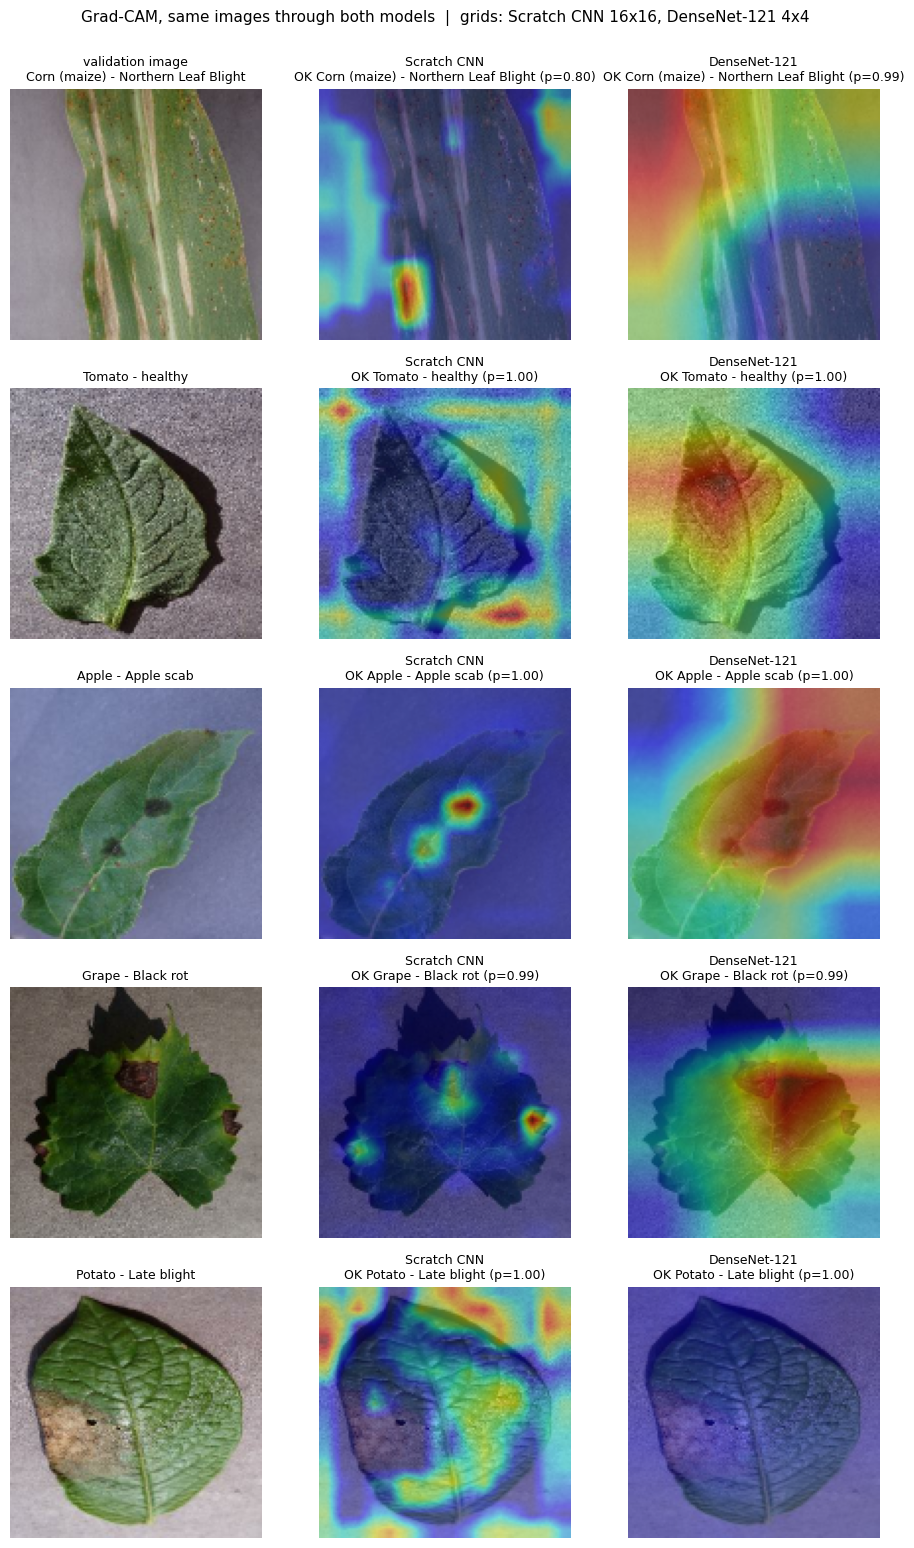

saved -> /content/drive/MyDrive/plant_recognition/deliverable2/04_figures/gradcam_paired_panel.png


In [ ]:
# Pick one validation image per requested class, then draw the paired panel
for c in PANEL_CLASSES:
    assert c in class_names, f"'{c}' is not a PlantVillage class. Available: {class_names}"

prng, picks = np.random.default_rng(SEED), []
for c in PANEL_CLASSES:
    cand = np.where(y_val == c)[0]
    assert len(cand), f"no validation images for {c}"
    picks.append(int(prng.choice(cand)))

pan_imgs = load_imgs(p_val[picks])
cams = {d: gradcam(d, pan_imgs) for d in ORDER}

fig, axes = plt.subplots(len(picks), 3, figsize=(9.5, 3.15 * len(picks)))
for r, gi in enumerate(picks):
    overlay(axes[r, 0], pan_imgs[r], None, pretty(y_val[gi]))
    for c, disp in enumerate(ORDER, start=1):
        cam, prob = cams[disp]
        k    = int(prob[r].argmax())
        mark = "OK " if k == yi_val[gi] else "MISS "
        overlay(axes[r, c], pan_imgs[r], cam[r],
                f"{disp}\n{mark}{pretty(class_names[k])} (p={prob[r, k]:.2f})")
axes[0, 0].set_title("validation image\n" + axes[0, 0].get_title(), fontsize=9)
fig.suptitle(f"Grad-CAM, same images through both models  |  grids: "
             f"{ORDER[0]} {grids[ORDER[0]][0]}x{grids[ORDER[0]][1]}, "
             f"{ORDER[1]} {grids[ORDER[1]][0]}x{grids[ORDER[1]][1]}", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(FIG["panel"], dpi=150, bbox_inches="tight")
plt.show()
print("saved ->", FIG["panel"])

## 8. Validation predictions for both models

One clean pass over the validation set per model, cached to `03_results/`. It gives §9 the list of images
DenseNet got wrong, and §11 the correct/incorrect flag each concentration is split by.

This is not a re-scoring of the models — the headline macro-F1 figures come from their own training
notebooks. It is printed here only as a consistency check: if these accuracies do not match what those
notebooks recorded, something is wrong with the checkpoint, not with the interpretability.

**Why run it:** outputs 2 and 4 both need to know which predictions were right.

**How it fits:** it is the join key between the heatmaps and the errors.

In [ ]:
# Predict the validation set with both models (cached)
if OUT["preds"].exists() and not FORCE_RECOMPUTE:
    preds = pd.read_csv(OUT["preds"])
    print(f"loaded cached predictions ({len(preds):,} rows) - FORCE_RECOMPUTE=True to redo")
else:
    n_pred = len(p_val) if not SMOKE_TEST else min(SMOKE_N * 4, len(p_val))
    rows = []
    for start in range(0, n_pred, BATCH_SIZE):
        sl   = slice(start, min(start + BATCH_SIZE, n_pred))
        imgs = load_imgs(p_val[sl])
        rec  = {d: nets[d].predict(imgs, verbose=0) for d in ORDER}
        for j, gi in enumerate(range(sl.start, sl.stop)):
            row = {"idx": gi, "label": y_val[gi], "y_true": int(yi_val[gi])}
            for d in ORDER:
                k = int(rec[d][j].argmax())
                row[f"{d} pred"] = k
                row[f"{d} conf"] = float(rec[d][j, k])
            rows.append(row)
        if start % (BATCH_SIZE * 40) == 0:
            print(f"  {sl.stop}/{n_pred}", end="\r")
    preds = pd.DataFrame(rows)
    preds.to_csv(OUT["preds"], index=False)
    print(f"\nwrote {len(preds):,} rows -> {OUT['preds']}")

print()
for d in ORDER:
    correct = (preds[f"{d} pred"] == preds["y_true"])
    print(f"{d:<14} accuracy on {len(preds):,} validation images: {correct.mean():.4f}  "
          f"({(~correct).sum():,} wrong)")


wrote 8,146 rows -> /content/drive/MyDrive/plant_recognition/deliverable2/03_results/val_predictions.csv

Scratch CNN    accuracy on 8,146 validation images: 0.9767  (190 wrong)
DenseNet-121   accuracy on 8,146 validation images: 0.9931  (56 wrong)


## 9. Output 2 — Grad-CAM on the DenseNet failures

A model at this accuracy fails rarely, and the failures are the only place its reasoning is visible under
strain. Each panel shows the image and the heatmap **for the class the model actually predicted** — the
question is what evidence it thought it had, not where the right evidence was.

Two patterns are worth naming when you read them. Heat sitting squarely on the leaf on a *wrong* prediction
means the model looked in the right place and misread the texture — a fine-grained confusion, and the
honest answer is that the two diseases look alike at 128 px. Heat sitting on background or frame edges means
the prediction never had leaf evidence behind it at all, which is the failure mode that does not survive
leaving the laboratory.

**Why run it:** an error table says which classes are confused; this says why.

**How it fits:** it is the error-analysis half of the interpretability section, and it feeds the confusion
pairs the report names.

DenseNet-121 failures: 56 of 8,146  ->  /content/drive/MyDrive/plant_recognition/deliverable2/03_results/densenet_failures.csv

most confident mistakes:
                                        true_label                                         pred_label  DenseNet-121 conf
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot                Corn_(maize)___Northern_Leaf_Blight           1.000000
               Corn_(maize)___Northern_Leaf_Blight Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot           0.985691
               Corn_(maize)___Northern_Leaf_Blight Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot           0.979219
     Tomato___Spider_mites Two-spotted_spider_mite                               Tomato___Target_Spot           0.968663
                              Tomato___Late_blight                               Tomato___Target_Spot           0.954440
            Tomato___Tomato_Yellow_Leaf_Curl_Virus                            Tomato___Bacterial_spot           0.953769


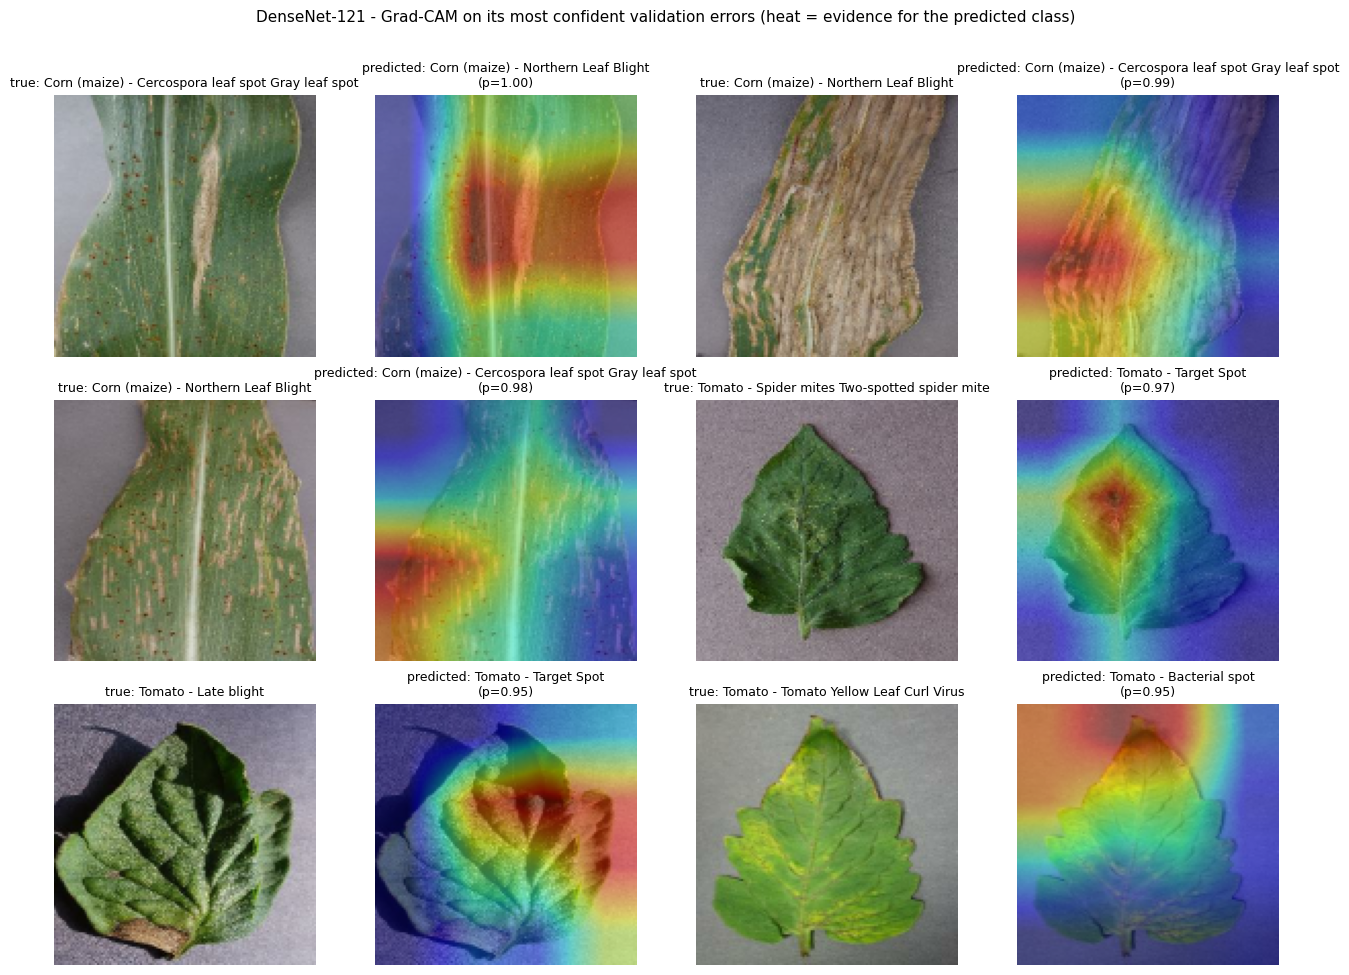

saved -> /content/drive/MyDrive/plant_recognition/deliverable2/04_figures/gradcam_densenet_failures.png


In [ ]:
# The DenseNet failures: full list to CSV, the first few drawn
fail = preds[preds[f"{DENSENET_NAME} pred"] != preds["y_true"]].copy()
fail["true_label"] = fail["label"]
fail["pred_label"] = [class_names[k] for k in fail[f"{DENSENET_NAME} pred"]]
fail = fail.sort_values(f"{DENSENET_NAME} conf", ascending=False)
fail[["idx", "true_label", "pred_label", f"{DENSENET_NAME} conf"]].to_csv(OUT["failures"], index=False)
print(f"{DENSENET_NAME} failures: {len(fail):,} of {len(preds):,}  ->  {OUT['failures']}")

if len(fail):
    print("\nmost confident mistakes:")
    print(fail[["true_label", "pred_label", f"{DENSENET_NAME} conf"]].head(8).to_string(index=False))
    print("\nmost frequent confusion pairs:")
    print(fail.groupby(["true_label", "pred_label"]).size()
              .sort_values(ascending=False).head(8).to_string())

    show  = fail.head(N_FAILURES)
    fimgs = load_imgs(p_val[show["idx"].values])
    fcam, fprob = gradcam(DENSENET_NAME, fimgs)

    n = len(show)
    fig, axes = plt.subplots(int(np.ceil(n / 2)), 4, figsize=(13, 3.3 * int(np.ceil(n / 2))))
    axes = np.atleast_2d(axes)
    for a in axes.ravel():
        a.axis("off")
    for k, (_, r) in enumerate(show.iterrows()):
        ro, co = k // 2, (k % 2) * 2
        overlay(axes[ro, co],     fimgs[k], None,    f"true: {pretty(r['true_label'])}")
        overlay(axes[ro, co + 1], fimgs[k], fcam[k],
                f"predicted: {pretty(r['pred_label'])}\n(p={r[f'{DENSENET_NAME} conf']:.2f})")
    fig.suptitle(f"{DENSENET_NAME} - Grad-CAM on its most confident validation errors "
                 f"(heat = evidence for the predicted class)", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(FIG["failures"], dpi=150, bbox_inches="tight")
    plt.show()
    print("saved ->", FIG["failures"])
else:
    print("no validation failures to draw.")

## 10. Output 3 — how much attention lands on the leaf

Heatmaps are persuasive and easy to over-read. This replaces the impression with a measurement.

PlantVillage ships a `segmented` rendering of every image — the same photograph with the background masked
to black, produced by the dataset's own authors. That gives a free per-image leaf mask. For each image:

- **leaf area** — the share of the frame the mask covers;
- **attention share** (on-leaf mass) — the share of the normalised Grad-CAM falling inside the mask;
- **concentration** — attention share ÷ leaf area.

Concentration is the number that means something. **1.0 is what a model looking nowhere in particular would
score** — heat spread evenly over the frame. Above 1.0 it concentrates on the leaf; below 1.0 it is
preferentially reading a background that carries no disease information whatsoever.

**The matched-resolution control.** The scratch CNN draws from a 16×16 grid and DenseNet from 4×4, and a
coarser grid is pulled mechanically toward the frame average — which is to say toward a concentration of
1.0 — regardless of what the model attends to. So a naive comparison partly measures the grid, not the
model. Alongside the native number we therefore recompute the scratch CNN's concentration from its own
heatmap **downsampled to 4×4 and back**, putting both models on the same spatial footing. If the two
models separate at native resolution but not at matched resolution, the difference was the grid. Both
columns go in the results file and the report should quote the matched one.

**Why run it:** it is the one interpretability result in this notebook that can be stated as a number.

**How it fits:** the field-robustness argument for the final model rests on the claim that it reads leaf
structure rather than acquisition artefacts. That claim is testable, and this is the test — with a paired
bootstrap so the answer comes with an error bar instead of a hand-wave.

In [ ]:
# On-leaf mass, leaf area and concentration, per image, per model (cached)
def load_mask(path):
    img = tf.io.decode_image(tf.io.read_file(str(path)), channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="nearest")
    return (tf.reduce_max(tf.cast(img, tf.float32), -1) > MASK_THRESH).numpy().astype("float32")

def coarsen(cam, g):
    """Downsample a (B,128,128) cam to a g x g grid and back, then renormalise."""
    t  = tf.image.resize(cam[..., None], [g, g], method="area")
    t  = tf.image.resize(t, [IMG_SIZE, IMG_SIZE])[..., 0]
    lo = tf.reduce_min(t, (1, 2), keepdims=True)
    hi = tf.reduce_max(t, (1, 2), keepdims=True)
    return ((t - lo) / tf.maximum(hi - lo, 1e-8)).numpy()

COARSE = min(grids[d][0] for d in ORDER)      # the coarser of the two grids

# O(1) correct/incorrect lookup, built once from the prediction table
correct_of = {d: dict(zip(preds["idx"], preds[f"{d} pred"] == preds["y_true"])) for d in ORDER}

if OUT["attention"].exists() and not FORCE_RECOMPUTE:
    att = pd.read_csv(OUT["attention"])
    print(f"loaded cached attention table ({len(att):,} rows) - FORCE_RECOMPUTE=True to redo")
else:
    idxs = sorted(mask_of)
    if N_ATTENTION is not None:
        idxs = list(np.random.default_rng(SEED).choice(idxs, size=min(N_ATTENTION, len(idxs)),
                                                       replace=False))
        idxs = sorted(int(i) for i in idxs)
    recs, flat_cams = [], 0
    for start in range(0, len(idxs), BATCH_SIZE):
        bi   = idxs[start:start + BATCH_SIZE]
        imgs = load_imgs(p_val[bi])
        msks = np.stack([load_mask(mask_of[i]) for i in bi])
        area = msks.mean((1, 2))
        for disp in ORDER:
            cam, prob = gradcam(disp, imgs)
            flat_cams += int(((cam.max((1, 2)) - cam.min((1, 2))) < 1e-6).sum())
            on   = (cam * msks).sum((1, 2)) / (cam.sum((1, 2)) + 1e-8)
            camc = coarsen(cam, COARSE)
            onc  = (camc * msks).sum((1, 2)) / (camc.sum((1, 2)) + 1e-8)
            for j, gi in enumerate(bi):
                recs.append({
                    "model": disp, "idx": gi, "label": y_val[gi],
                    "leaf_area": float(area[j]),
                    "on_leaf": float(on[j]),
                    "concentration": float(on[j] / max(area[j], 1e-6)),
                    "on_leaf_matched": float(onc[j]),
                    "concentration_matched": float(onc[j] / max(area[j], 1e-6)),
                    "correct": correct_of[disp].get(gi),
                })
        if start % (BATCH_SIZE * 20) == 0:
            print(f"  {min(start + BATCH_SIZE, len(idxs))}/{len(idxs)} images", end="\r")
    att = pd.DataFrame(recs)
    att.to_csv(OUT["attention"], index=False)
    print(f"\nwrote {len(att):,} rows -> {OUT['attention']}")
    if flat_cams:
        print(f"note: {flat_cams} degenerate (flat) Grad-CAMs encountered - "
              "their concentration is undefined and they sit at 0.")

summary = (att.groupby("model")
             .agg(n=("idx", "size"),
                  leaf_area=("leaf_area", "mean"),
                  attention_share=("on_leaf", "mean"),
                  concentration=("concentration", "mean"),
                  concentration_matched=("concentration_matched", "mean"))
             .reindex(ORDER).round(3))
print(f"\nAttention inside the dataset's own leaf masks ({len(att)//len(ORDER):,} images, "
      f"1.00 = no preference):\n")
print(summary.to_string())


wrote 15,934 rows -> /content/drive/MyDrive/plant_recognition/deliverable2/03_results/attention_on_leaf.csv
note: 80 degenerate (flat) Grad-CAMs encountered - their concentration is undefined and they sit at 0.

Attention inside the dataset's own leaf masks (7,967 images, 1.00 = no preference):

                 n  leaf_area  attention_share  concentration  concentration_matched
model                                                                               
Scratch CNN   7967      0.474            0.567          1.226                  1.169
DenseNet-121  7967      0.474            0.533          1.148                  1.134


In [ ]:
# Paired bootstrap on the difference between the two models, native and matched resolution
a, b = ORDER
lines = []
for col in ("concentration", "concentration_matched"):
    wide = att.pivot(index="idx", columns="model", values=col).dropna()
    diff = (wide[b] - wide[a]).values
    n    = len(diff)
    boot = diff[np.random.default_rng(SEED).integers(0, n, (N_BOOT, n))].mean(1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    sig = lo * hi > 0
    lines.append({"metric": col, "n_paired": n,
                  f"{a}": round(float(wide[a].mean()), 4),
                  f"{b}": round(float(wide[b].mean()), 4),
                  "difference": round(float(diff.mean()), 4),
                  "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
                  "distinguishable_from_zero": bool(sig)})
    print(f"[{col}]  paired on {n:,} images")
    print(f"   {a}: {wide[a].mean():.3f}    {b}: {wide[b].mean():.3f}")
    print(f"   difference ({b} - {a}): {diff.mean():+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]")
    print("   -> " + ("distinguishable from zero.\n" if sig else
                      "NOT distinguishable - the two models attend to the leaf equally.\n"))

summary.reset_index().to_csv(OUT["summary"], index=False)
pd.DataFrame(lines).to_csv(OUT["bootstrap"], index=False)
print("saved ->", OUT["summary"])
print("saved ->", OUT["bootstrap"])

[concentration]  paired on 7,967 images
   Scratch CNN: 1.226    DenseNet-121: 1.148
   difference (DenseNet-121 - Scratch CNN): -0.078   95% CI [-0.090, -0.066]
   -> distinguishable from zero.

[concentration_matched]  paired on 7,967 images
   Scratch CNN: 1.169    DenseNet-121: 1.134
   difference (DenseNet-121 - Scratch CNN): -0.034   95% CI [-0.043, -0.025]
   -> distinguishable from zero.

saved -> /content/drive/MyDrive/plant_recognition/deliverable2/03_results/attention_summary.csv
saved -> /content/drive/MyDrive/plant_recognition/deliverable2/03_results/attention_bootstrap.csv


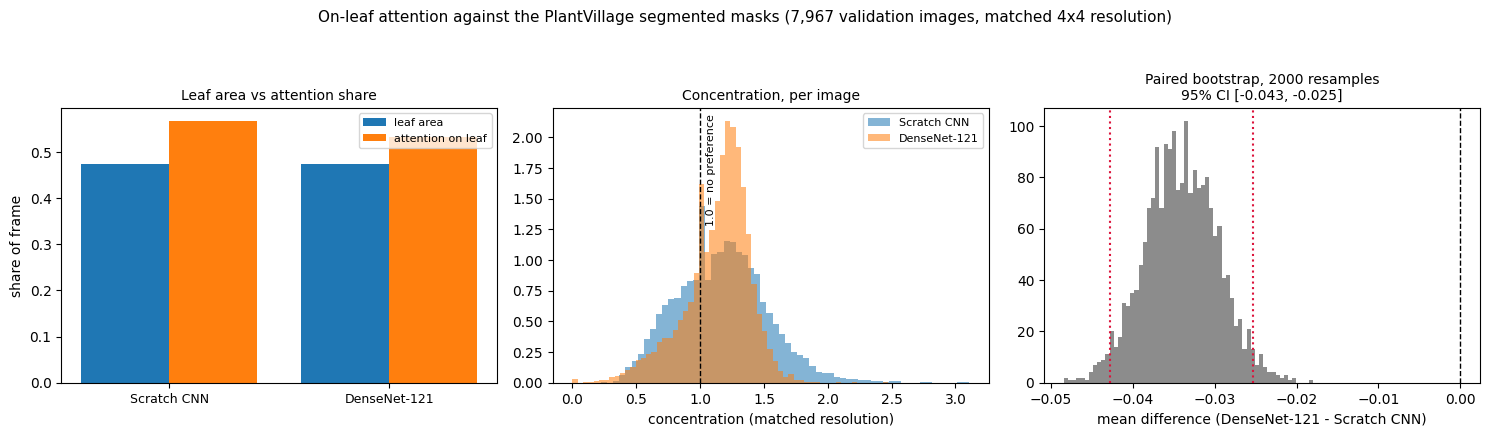

saved -> /content/drive/MyDrive/plant_recognition/deliverable2/04_figures/attention_on_leaf.png


In [ ]:
# Figure: where the attention goes, and how confident we are in the gap
wide = att.pivot(index="idx", columns="model", values="concentration_matched").dropna()
diff = (wide[b] - wide[a]).values
boot = diff[np.random.default_rng(SEED).integers(0, len(diff), (N_BOOT, len(diff)))].mean(1)
lo, hi = np.percentile(boot, [2.5, 97.5])

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

x = np.arange(len(ORDER))
ax[0].bar(x - 0.2, [summary.loc[d, "leaf_area"] for d in ORDER], 0.4, label="leaf area")
ax[0].bar(x + 0.2, [summary.loc[d, "attention_share"] for d in ORDER], 0.4, label="attention on leaf")
ax[0].set_xticks(x); ax[0].set_xticklabels(ORDER, fontsize=9)
ax[0].set_ylabel("share of frame"); ax[0].legend(fontsize=8)
ax[0].set_title("Leaf area vs attention share", fontsize=10)

for d in ORDER:
    ax[1].hist(att.loc[att["model"] == d, "concentration_matched"], bins=60,
               alpha=0.55, label=d, density=True)
ax[1].axvline(1.0, ls="--", c="k", lw=1)
ax[1].set_xlim(min(ax[1].get_xlim()[0], 0.92), ax[1].get_xlim()[1])   # always show the 1.0 line
ax[1].annotate("1.0 = no preference", xy=(1.0, ax[1].get_ylim()[1]), xytext=(4, -4),
               textcoords="offset points", fontsize=8, va="top", rotation=90)
ax[1].set_xlabel("concentration (matched resolution)"); ax[1].legend(fontsize=8)
ax[1].set_title("Concentration, per image", fontsize=10)

ax[2].hist(boot, bins=60, color="0.55")
ax[2].axvline(0, ls="--", c="k", lw=1)
ax[2].axvline(lo, ls=":", c="crimson"); ax[2].axvline(hi, ls=":", c="crimson")
ax[2].set_xlabel(f"mean difference ({b} - {a})")
ax[2].set_title(f"Paired bootstrap, {N_BOOT} resamples\n95% CI [{lo:+.3f}, {hi:+.3f}]", fontsize=10)

fig.suptitle("On-leaf attention against the PlantVillage segmented masks "
             f"({len(wide):,} validation images, matched {COARSE}x{COARSE} resolution)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG["attention"], dpi=150, bbox_inches="tight")
plt.show()
print("saved ->", FIG["attention"])

## 11. Output 4 — is the correct-vs-wrong gap real?

The scratch CNN was recorded at concentration **1.229** on images it classified correctly and **1.128** on
images it got wrong. The direction is what you would hope for — *when it fails, it was looking in the wrong
place* — but the gap was never tested, and an untested gap is an anecdote. This is the test, run for both
models.

**How it is tested.** The two groups are wildly unequal in size (thousands correct, tens or hundreds wrong)
and concentration is not normally distributed, so the headline test is **Mann–Whitney U**, which assumes
neither. Welch's t-test is reported beside it as a cross-check, and a bootstrap gives a confidence interval
on the difference in means, which is the quantity the report actually quotes. The **rank-biserial
correlation** is the effect size: it is the probability that a randomly chosen correct image out-concentrates
a randomly chosen wrong one, rescaled to [−1, 1], and it is the number to look at before calling anything
important.

**Two honesty notes.** Two models are tested, so a Bonferroni-corrected threshold is **p < 0.025**, not 0.05.
And DenseNet fails on very few validation images — if its wrong group is in the tens, the test is
underpowered and a null result there means *not enough failures to tell*, which is a different statement
from *no effect*. The printout gives the group sizes so this cannot be glossed over.

**Why run it:** it closes an open item that was flagged as suggestive-only.

**How it fits:** if the gap holds, "the model fails when it looks in the wrong place" becomes a supported
claim rather than a plausible story — and that is the sentence the field-robustness section rests on.

In [ ]:
# Correct vs wrong concentration, tested properly, for both models
rows = []
for disp in ORDER:
    sub = att[(att["model"] == disp) & att["correct"].notna()]
    for col in ("concentration", "concentration_matched"):
        c = sub.loc[sub["correct"].astype(bool), col].values
        w = sub.loc[~sub["correct"].astype(bool), col].values
        if len(w) < 2 or len(c) < 2:
            rows.append({"model": disp, "metric": col, "n_correct": len(c), "n_wrong": len(w),
                         "note": "too few failures to test"})
            continue
        u, p_mw = stats.mannwhitneyu(c, w, alternative="two-sided")
        t, p_t  = stats.ttest_ind(c, w, equal_var=False)
        rb      = 2 * u / (len(c) * len(w)) - 1               # rank-biserial effect size
        rng2    = np.random.default_rng(SEED)
        bs      = (c[rng2.integers(0, len(c), (N_BOOT, len(c)))].mean(1)
                   - w[rng2.integers(0, len(w), (N_BOOT, len(w)))].mean(1))
        lo, hi  = np.percentile(bs, [2.5, 97.5])
        rows.append({"model": disp, "metric": col,
                     "n_correct": len(c), "n_wrong": len(w),
                     "mean_correct": round(float(c.mean()), 4),
                     "mean_wrong": round(float(w.mean()), 4),
                     "difference": round(float(c.mean() - w.mean()), 4),
                     "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
                     "mannwhitney_p": float(p_mw), "welch_p": float(p_t),
                     "rank_biserial": round(float(rb), 4),
                     "mw_significant_0.025": bool(p_mw < 0.025),
                     "ci_excludes_zero": bool(lo * hi > 0),
                     "verdict": ("supported" if (p_mw < 0.025) and (lo * hi > 0)
                                 else "not supported" if (p_mw >= 0.025) and (lo * hi <= 0)
                                 else "mixed")})

cw = pd.DataFrame(rows)
cw.to_csv(OUT["corrwrong"], index=False)

print("Concentration on images the model got right vs wrong\n")
for _, r in cw.iterrows():
    if "note" in r and isinstance(r.get("note"), str):
        print(f"{r['model']} [{r['metric']}]: {r['note']} "
              f"(correct {r['n_correct']}, wrong {r['n_wrong']})\n")
        continue
    print(f"{r['model']} [{r['metric']}]  n = {r['n_correct']:,} correct / {r['n_wrong']:,} wrong")
    print(f"   correct {r['mean_correct']:.3f}   wrong {r['mean_wrong']:.3f}   "
          f"difference {r['difference']:+.3f}  95% CI [{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]")
    print(f"   Mann-Whitney p = {r['mannwhitney_p']:.2e}   Welch p = {r['welch_p']:.2e}   "
          f"rank-biserial = {r['rank_biserial']:+.3f}")
    print(f"   -> {r['verdict'].upper()}")
    if r["verdict"] == "mixed":
        print("      the rank test and the mean-difference CI disagree. Mann-Whitney tests whether the")
        print("      two distributions are shifted; the CI asks whether the difference in MEANS is")
        print("      resolved at this n. Report both, and quote the CI - it is the mean the report cites.")
    print()
print("saved ->", OUT["corrwrong"])

Concentration on images the model got right vs wrong

Scratch CNN [concentration]  n = 7,777 correct / 190 wrong
   correct 1.229   wrong 1.127   difference +0.101  95% CI [+0.008, +0.189]
   Mann-Whitney p = 3.19e-05   Welch p = 3.48e-02   rank-biserial = +0.176
   -> SUPPORTED

Scratch CNN [concentration_matched]  n = 7,777 correct / 190 wrong
   correct 1.171   wrong 1.079   difference +0.091  95% CI [+0.031, +0.149]
   Mann-Whitney p = 4.39e-06   Welch p = 3.78e-03   rank-biserial = +0.195
   -> SUPPORTED

DenseNet-121 [concentration]  n = 7,911 correct / 56 wrong
   correct 1.149   wrong 1.015   difference +0.134  95% CI [+0.046, +0.226]
   Mann-Whitney p = 2.70e-03   Welch p = 6.30e-03   rank-biserial = +0.232
   -> SUPPORTED

DenseNet-121 [concentration_matched]  n = 7,911 correct / 56 wrong
   correct 1.135   wrong 1.009   difference +0.126  95% CI [+0.053, +0.203]
   Mann-Whitney p = 7.13e-04   Welch p = 2.11e-03   rank-biserial = +0.262
   -> SUPPORTED

saved -> /content/driv

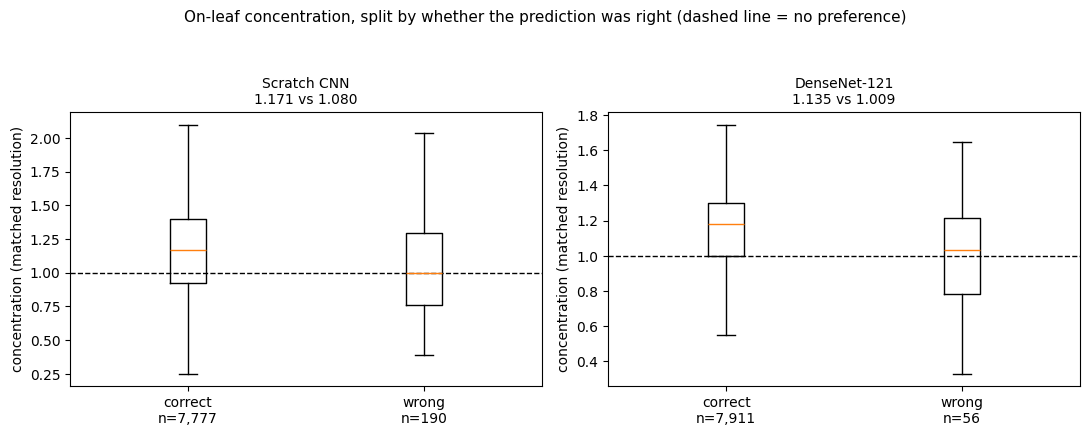

saved -> /content/drive/MyDrive/plant_recognition/deliverable2/04_figures/attention_correct_vs_wrong.png


In [ ]:
# Figure: the two distributions, per model
fig, ax = plt.subplots(1, len(ORDER), figsize=(5.5 * len(ORDER), 4.4), squeeze=False)
for k, disp in enumerate(ORDER):
    sub = att[(att["model"] == disp) & att["correct"].notna()]
    c = sub.loc[sub["correct"].astype(bool), "concentration_matched"].values
    w = sub.loc[~sub["correct"].astype(bool), "concentration_matched"].values
    a_ = ax[0, k]
    a_.boxplot([c, w], showfliers=False)
    a_.set_xticks([1, 2])
    a_.set_xticklabels([f"correct\nn={len(c):,}", f"wrong\nn={len(w):,}"])
    a_.axhline(1.0, ls="--", c="k", lw=1)
    if len(c) and len(w):
        a_.set_title(f"{disp}\n{c.mean():.3f} vs {w.mean():.3f}", fontsize=10)
    else:
        a_.set_title(disp, fontsize=10)
    a_.set_ylabel("concentration (matched resolution)")
fig.suptitle("On-leaf concentration, split by whether the prediction was right "
             "(dashed line = no preference)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG["corrwrong"], dpi=150, bbox_inches="tight")
plt.show()
print("saved ->", FIG["corrwrong"])

## 12. What this produced

**Figures — `04_figures/`**

| File | What it shows |
|---|---|
| `gradcam_paired_panel.png` | Output 1 — five validation images, both models, side by side |
| `gradcam_densenet_failures.png` | Output 2 — what DenseNet was looking at when it was wrong |
| `attention_on_leaf.png` | Output 3 — leaf area vs attention share, concentration, bootstrap |
| `attention_correct_vs_wrong.png` | Output 4 — concentration split by whether the prediction was right |

**Numbers — `03_results/`**

| File | Contents |
|---|---|
| `val_predictions.csv` | Per-image prediction and confidence, both models |
| `densenet_failures.csv` | Every DenseNet validation error, with true and predicted class |
| `attention_summary.csv` | Leaf area, attention share, concentration — native and matched — per model |
| `attention_bootstrap.csv` | The paired between-model difference with its 95% CI, both resolutions |
| `attention_on_leaf.csv` | The per-image table all of the above is computed from |
| `attention_correct_vs_wrong.csv` | Mann–Whitney, Welch, bootstrap CI and effect size, per model |

**Reading the concentration result.** Quote the **matched-resolution** column in the report and say why —
the native comparison is partly a comparison of 16×16 against 4×4. Whichever way it falls is a result:
if DenseNet concentrates harder on the leaf, the field-robustness argument is measured rather than asserted;
if the two are indistinguishable, say so plainly; if DenseNet is *worse*, that is the most interesting
finding in the report and the final-model choice deserves re-examining **before** the test set is opened.

**What this does not show.** Grad-CAM answers one question — where the evidence for the chosen class was.
It does not say what would have changed the model's mind, and a high concentration is not proof of
understanding: a model can read the right region for the wrong reason. It is a diagnostic, and it should be
reported as one.

**The test set is still sealed.** Nothing above touched it.